# Localization

Localization finds where a new photo was taken: a query image goes in, and its camera pose in the
reconstruction comes out, along with a refined focal length. This page localizes two photos: a
frame of the tutorial video, whose pose is already known, and a frame from a different video of
the same place.

In [1]:
import contextlib
import io

import numpy as np
from scipy.spatial.distance import pdist
from scipy.spatial.transform import Rotation

from collab_splats.geometry.transforms import invert_poses
from collab_splats.localization import (
    CameraLocalizer,
    LocalMatcher,
    correspondences_for_ref,
    plot_correspondences,
    plot_inlier_distribution,
)
from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc import frames
from collab_splats.utils.io import read_image
from collab_splats.utils.visualization import (
    camera_view,
    create_camera_frustum_pyvista,
    plot_reprojection,
    pointcloud_to_polydata,
    visualize_splat,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud")

## 1. The feature database

For every keyframe the localizer stores one summary descriptor (to find similar keyframes),
local keypoints (to match pixels), and the 3D point under every pixel.

Build the database from the reconstruction:

In [2]:
dense = PointcloudResult.load_zarr(
    scene.pointcloud_zarr, load_depth=False, load_confidence=False, load_pixel_indices=False
)
frame_ids = [frames.frame_idx_from_path(p) for p in dense.image_paths]
images = frames.read_frames(scene.images_dir, frame_ids)

# Hide model-loading output
with contextlib.redirect_stderr(io.StringIO()):
    loc = CameraLocalizer.from_pointcloud(
        dense,
        zarr_path=work_dir("localization") / "features.zarr",
        images=images,
        extractor=LocalMatcher("loma"),
    )

## 2. A frame from the video

Localization runs in three steps:

1. Retrieve: find the keyframes that look most like the query.
2. Match: pair up pixels between the query and those keyframes.
3. Solve: the matched keyframe pixels have known 3D points, so the query pose that best
   explains where those points appear in the query is solved for (PnP with RANSAC). Matches
   that fit the pose are **inliers**; the rest are discarded.

Localize frame 0 of the tutorial video:

In [3]:
ref_query = read_image(REF_FRAME)
ref_pose = loc.localize(ref_query)
print(f"{ref_pose.n_inliers} of {ref_pose.n_correspondences} matches are inliers")

3262 of 7269 matches are inliers


The reconstruction has its own pose for frame 0, so the two can be compared. The scene has no
real-world scale, so the position error is given as a share of the camera path's size.

In [4]:
assert ref_pose.pose is not None, "localization failed on the in-video frame"
assert 0 in frame_ids, f"frame 0 is not a keyframe; keyframes start at {frame_ids[:3]}"
fitted = dense.extrinsics[frame_ids.index(0)]

# Rotation error: angle of the rotation between the two poses
relative = ref_pose.pose @ invert_poses(fitted)
rotation_error = np.degrees(Rotation.from_matrix(relative[:3, :3]).magnitude())

# Position error over the size of the camera path
centers = invert_poses(dense.extrinsics)[:, :3, 3]
offset = invert_poses(ref_pose.pose)[:3, 3] - invert_poses(fitted)[:3, 3]
path_size = pdist(centers).max()

print(f"rotation error: {rotation_error:.2f} deg")
print(f"position error: {np.linalg.norm(offset) / path_size:.2%} of the path size")

rotation error: 0.13 deg
position error: 0.04% of the path size


Both errors should be small. This only checks that the steps agree: the reconstruction already
used this frame, so it says nothing about how well an unseen photo localizes.

## 3. A frame from another video

The second query is a landscape frame from a different camera. There is no known pose for it, so
the checks below are visual.

In [5]:
query = read_image(QUERY_IMAGE)
pose = loc.localize(query)
assert pose.pose is not None, "localization failed on the cross-video frame"
print(f"{pose.n_inliers} of {pose.n_correspondences} matches are inliers")
print(f"refined focal length: {pose.query_intrinsics[0, 0]:.0f} px")

1566 of 4375 matches are inliers
refined focal length: 2804 px


Inlier matches against the keyframe that gave the most:

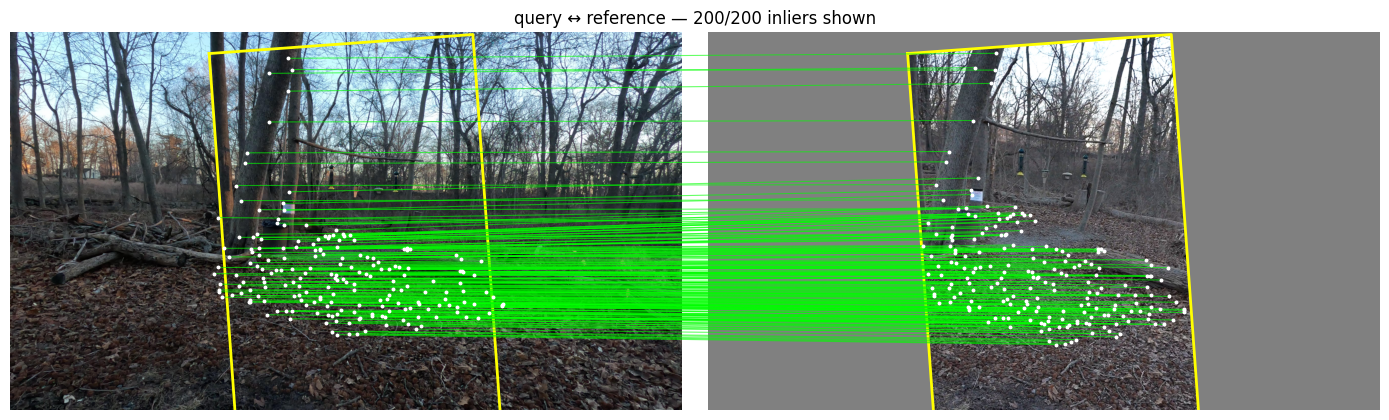

In [6]:
best = pose.ranked_ref_frames[0]
ref_image = images[best]
query_px, ref_px, inliers = correspondences_for_ref(pose, best, ref_image.shape[:2])
fig = plot_correspondences(query, ref_image, query_px[inliers], ref_px[inliers], align=True)

Each green line joins the same point in both images. On the right, the keyframe is scaled,
rotated and shifted to sit where the query sees it, and the yellow box marks its edges in both. The
lines come out roughly level; a flat image cannot match a 3D scene exactly, so some lean.

Which keyframes the inliers came from:

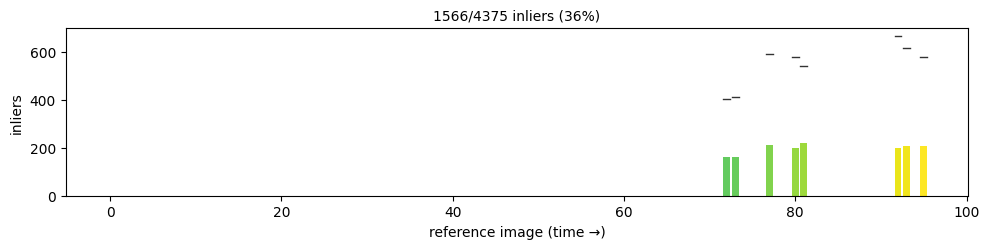

In [7]:
fig = plot_inlier_distribution(pose.ref_frame_indices, pose.inlier_mask, len(frame_ids))

Bars are keyframes in time order; the dashes mark each keyframe's total matches and the bar the
inliers. Inliers should come from a few neighboring keyframes that see what the query sees.

The query camera (red) in the scene, with the keyframe cameras colored by time:

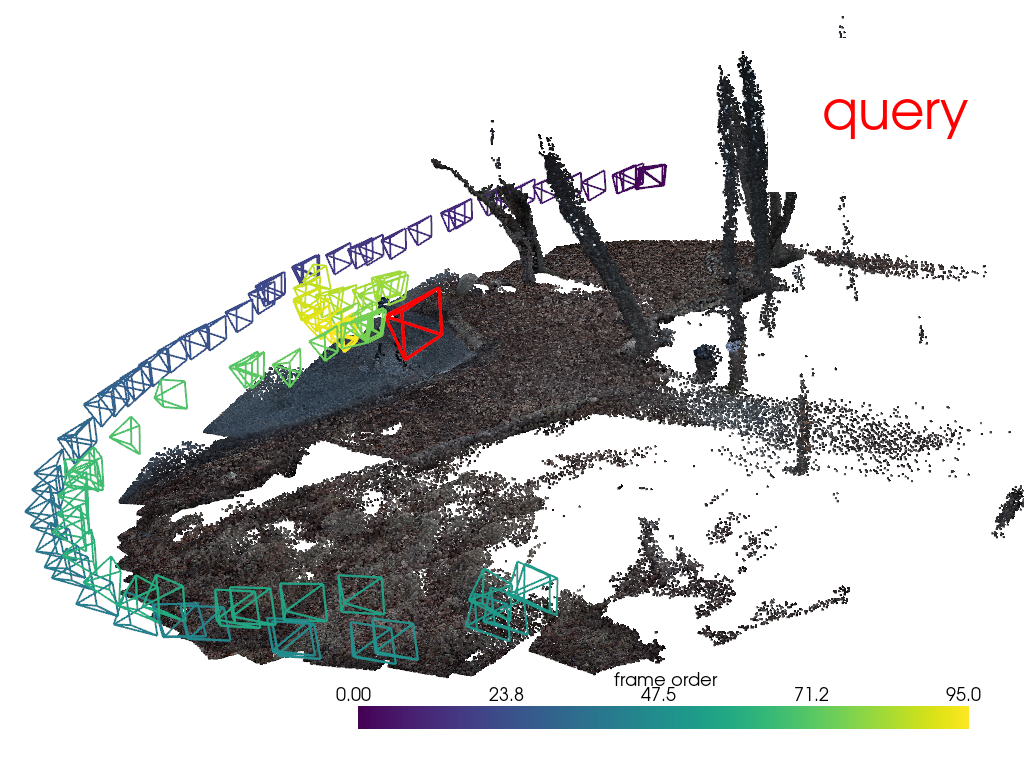

In [8]:
cloud = pointcloud_to_polydata(dense.points, RGB=dense.colors)
lo, hi = np.percentile(dense.points, [5, 95], axis=0)
scale = 0.005 * np.linalg.norm(hi - lo)

plotter = visualize_splat(
    cloud,
    dense.extrinsics,
    camera_kwargs={"scale": scale, "n_poses": 1, "line_width": 2},
    viz_kwargs=camera_view(dense.extrinsics, dense.points),
)
query_frustum = create_camera_frustum_pyvista(pose.pose, scale=2 * scale)
plotter.add_mesh(query_frustum, color="red", line_width=3)
plotter.add_legend([("query", "red")], bcolor="white")
plotter.show()

The red camera should sit near the keyframes that gave its inliers and face the same way.

The point cloud rendered from the solved pose, next to the photo and blended with it:

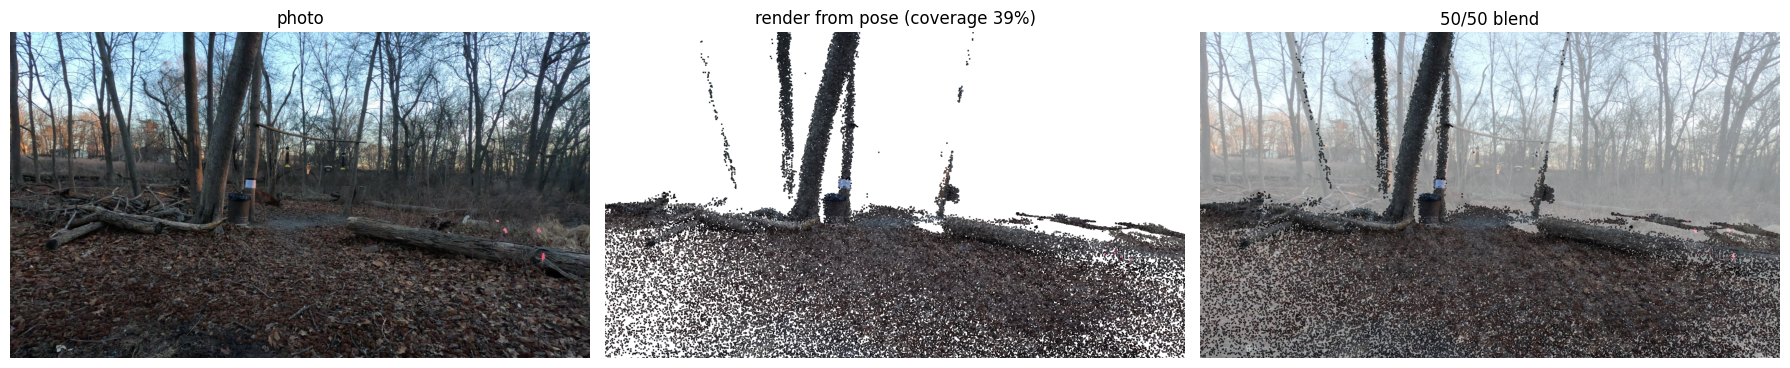

In [9]:
fig = plot_reprojection(query, dense.points, dense.colors, pose.pose, pose.query_intrinsics)

If the pose is right, edges in the render line up with the same edges in the photo.

## In a pipeline run

The `localize` stage builds the same database inside `pointcloud.zarr`. `matcher` is `loma` or
`xfeat` (lighter, fewer matches). The `refine` stage rewrites `pointcloud.zarr`, so `localize`
runs after it.

```yaml
localization:
  enabled: true
  matcher: loma   # loma | xfeat
```